In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [36]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.info)
print('//////////')
print(df.describe())#prints statistical summary of numerical columns in the dataset.
print('//////////')
print(df.isnull().sum())#is used to check missing values in each column


<bound method DataFrame.info of       customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0     7590-VHVEG  Female              0  ...          29.85        29.85     No
1     5575-GNVDE    Male              0  ...          56.95       1889.5     No
2     3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3     7795-CFOCW    Male              0  ...          42.30      1840.75     No
4     9237-HQITU  Female              0  ...          70.70       151.65    Yes
...          ...     ...            ...  ...            ...          ...    ...
7038  6840-RESVB    Male              0  ...          84.80       1990.5     No
7039  2234-XADUH  Female              0  ...         103.20       7362.9     No
7040  4801-JZAZL  Female              0  ...          29.60       346.45     No
7041  8361-LTMKD    Male              1  ...          74.40        306.6    Yes
7042  3186-AJIEK    Male              0  ...         105.65       6844.5     No

[7043 r

In [37]:
df.drop('customerID', axis=1, inplace=True)#It deletes the customerID column from the dataset permanently.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')#changes the coumn to number generaly float and if any value cant be converted just do it nan


df.dropna(inplace=True)#It deletes all rows that have missing data in any column.


le = LabelEncoder()#converts text (categorical data) into numbers.
for col in df.columns:#goes through every column in the dataset.
    if df[col].dtype == 'object':#check if the colum contain text values
        df[col] = le.fit_transform(df[col])#convert each text value into number

In [38]:
X = df.drop('Churn', axis=1)#create x (features) taking all columns except Churn
y = df['Churn']#create y(target/label) which contain only Churn Column

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=2,random_state=42)

In [39]:
models = {
    'logistic Regression' : LogisticRegression(max_iter=1000),
    'Descision Tree': DecisionTreeClassifier(),
    'Random Forest' : RandomForestClassifier(),
    'K-nearest Neighbors' : KNeighborsClassifier()
}

results = []

for name,model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name,acc))

    print(f"\n📊 {name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


📊 logistic Regression Results:
Accuracy: 1.0
Confusion Matrix:
 [[2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


📊 Descision Tree Results:
Accuracy: 1.0
Confusion Matrix:
 [[2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



c:\Users\vatsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\vatsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



📊 Random Forest Results:
Accuracy: 1.0
Confusion Matrix:
 [[2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


📊 K-nearest Neighbors Results:
Accuracy: 1.0
Confusion Matrix:
 [[2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



c:\Users\vatsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\vatsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


C:\Users\vatsa\AppData\Local\Temp\ipykernel_22116\1603306355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")


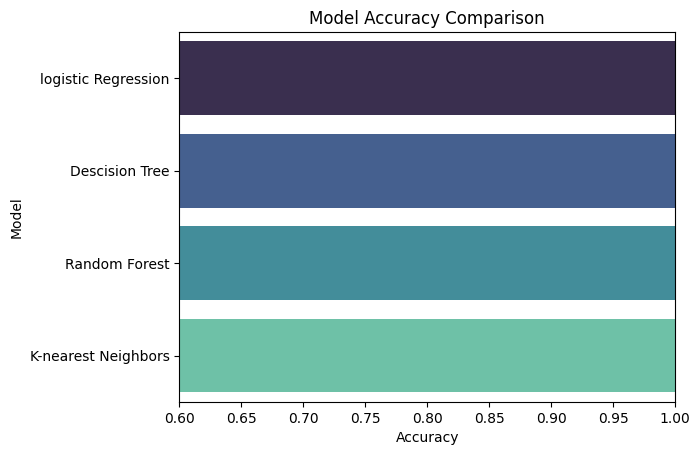

In [42]:

# Create results DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# Plot
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlim(0.6, 1.0)
plt.show()

VISUALIZATION

C:\Users\vatsa\AppData\Local\Temp\ipykernel_22116\3454828695.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


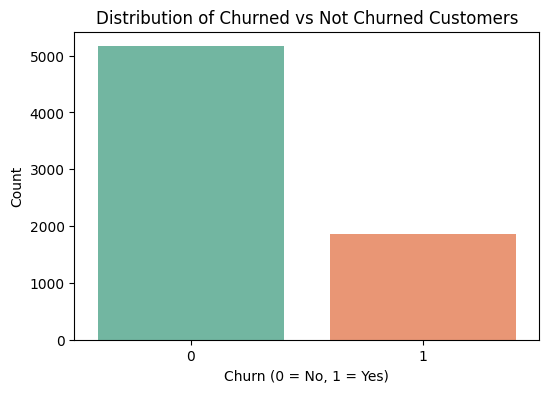

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
# Counts how many 0 and 1 values exist in the Churn column.
# | Churn | Meaning         |
# | ----- | --------------- |
# | 0     | Customer stayed |
# | 1     | Customer left   |
plt.title('Distribution of Churned vs Not Churned Customers')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

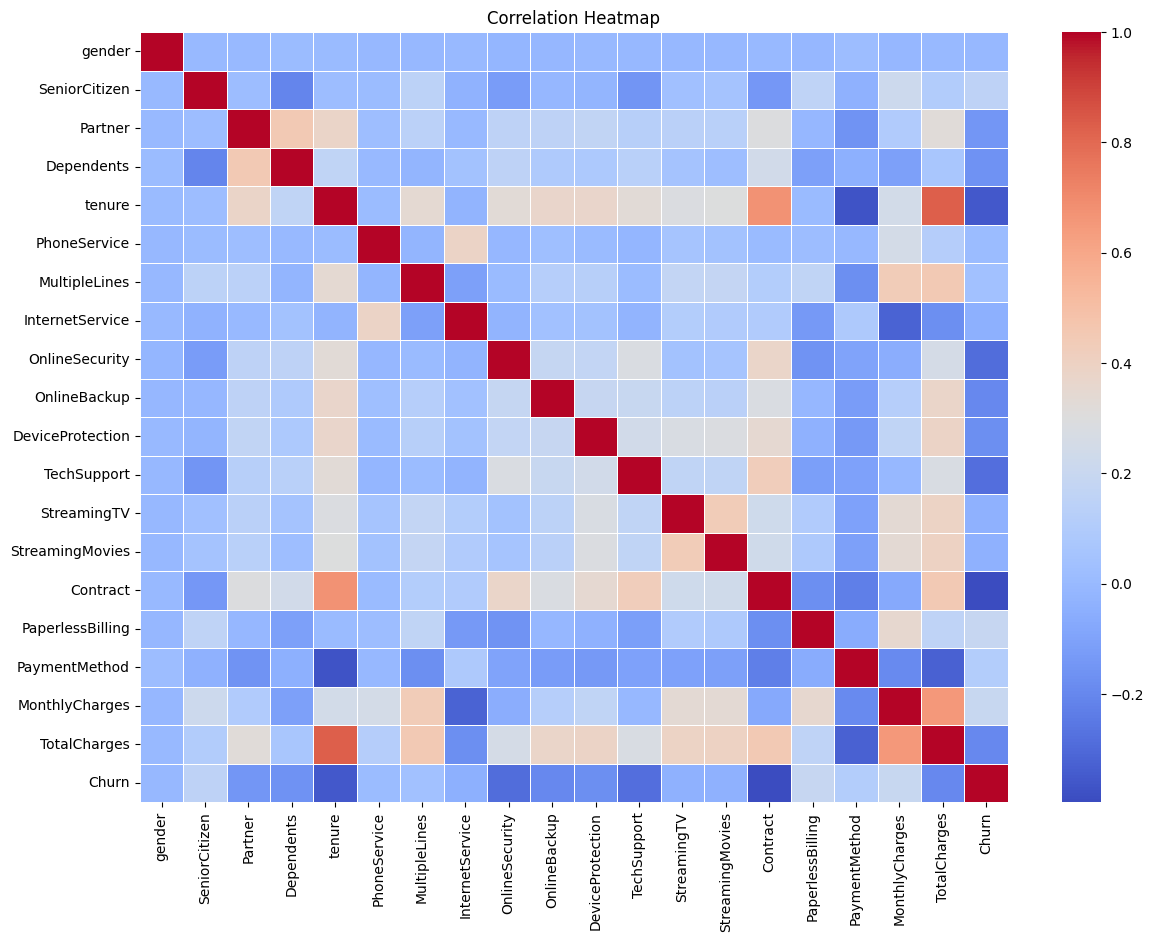

In [ ]:
plt.figure(figsize=(14,10))
corr = df.corr()#Correlation shows how strongly two variables are related.
# Values range from:
# 1 → strong positive relationship
# 0 → no relationship
# -1 → strong negative relationship
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

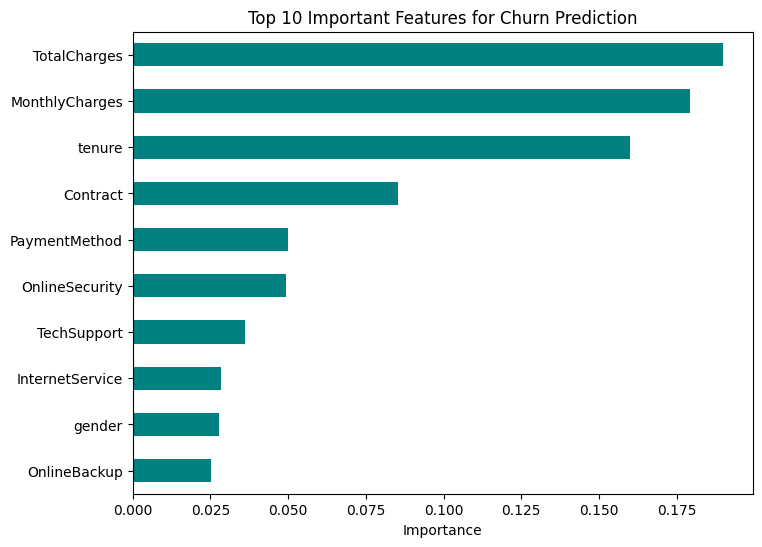

In [ ]:
# Train Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Plot feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
#rf.feature_importances_ → gives importance score of each feature.
# index=X.columns → attaches feature names to those scores.
# Higher number = more important for prediction.

importances.nlargest(10).plot(kind='barh', figsize=(8,6), color='teal')
plt.title('Top 10 Important Features for Churn Prediction')
plt.xlabel('Importance')
plt.gca().invert_yaxis()#Puts the most important feature at the top.
plt.show()


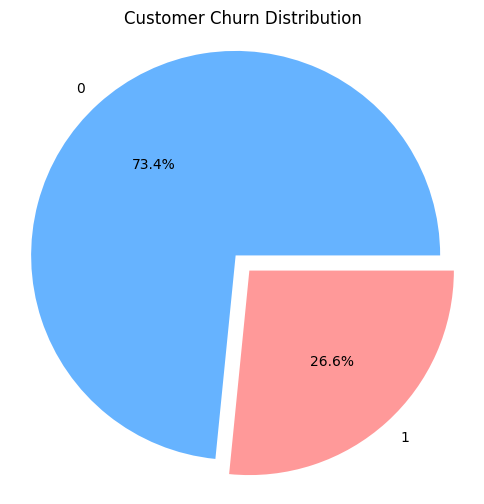

In [46]:
import matplotlib.pyplot as plt

# Pie chart for churn distribution
churn_counts = df['Churn'].value_counts()
labels = churn_counts.index
sizes = churn_counts.values
colors = ['#66b3ff','#ff9999']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=(0, 0.1))
plt.title('Customer Churn Distribution')
plt.axis('equal')
plt.show()

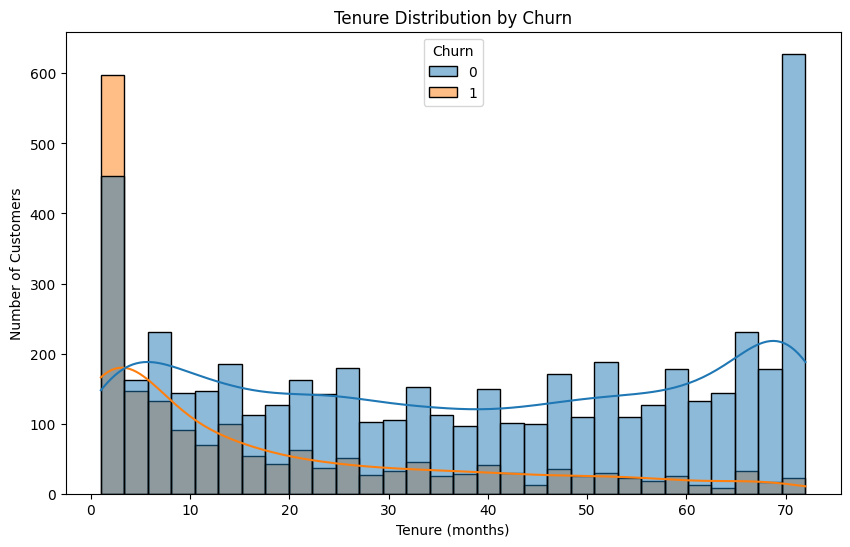

In [47]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

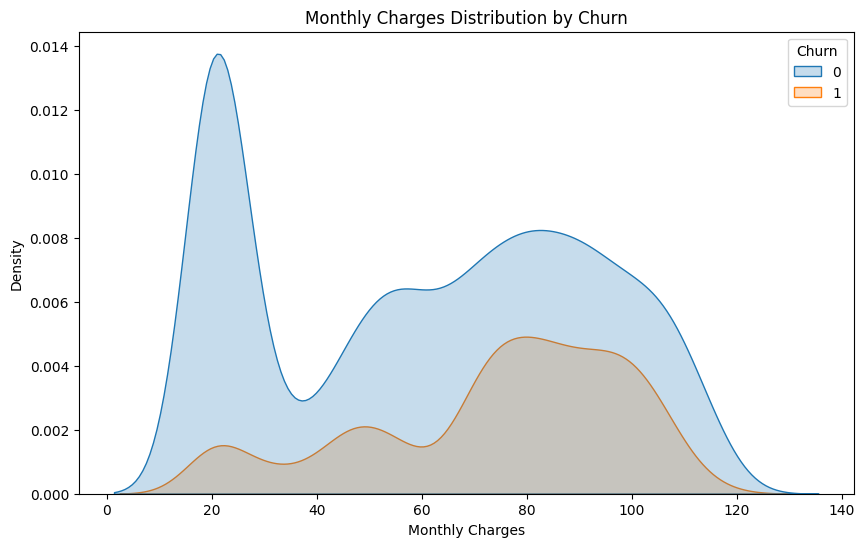

In [48]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True)
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()

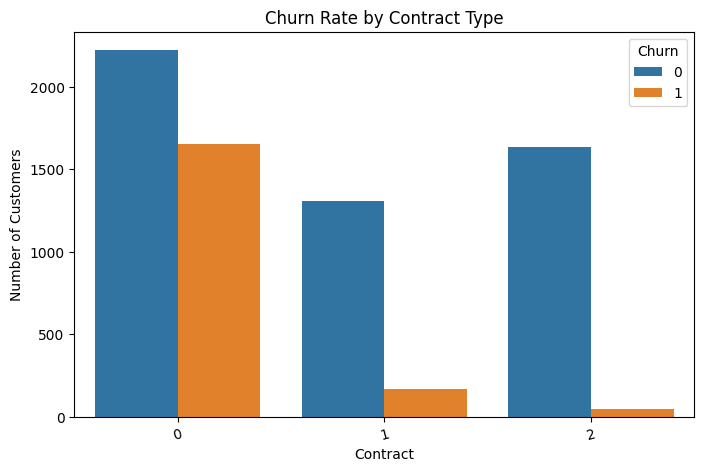

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

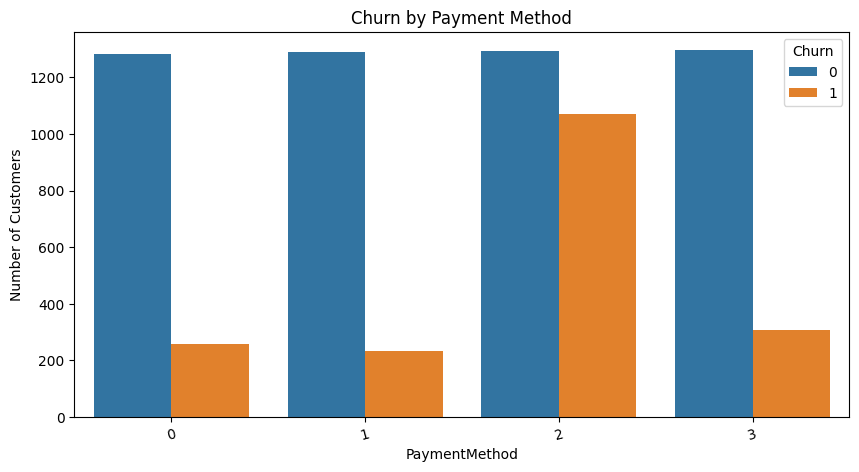

In [50]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()